In [ ]:
import os
import re
import pandas

os.chdir(r'L:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20241118')

In [ ]:
ref_letter = pandas.read_sas(r'refletter_20241118.sas7bdat', encoding='latin1')
ref_letter = ref_letter.dropna(subset=['PASBLOB_RTF_text']).reset_index(drop=True)
ref_letter = ref_letter.rename(columns={'PASBLOB_RTF_text': 'text'})
ref_letter = ref_letter.assign(text_len=ref_letter.text.apply(lambda x: len(x.split(" "))))

<Axes: >

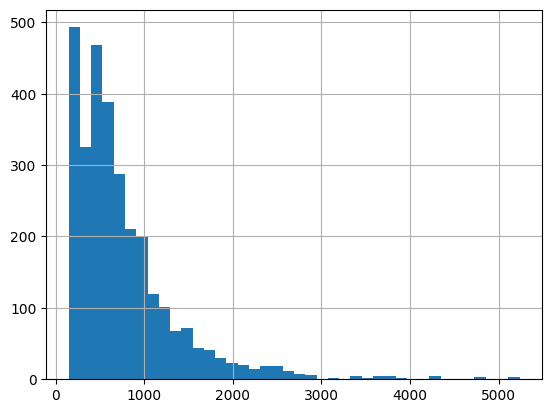

In [61]:
ref_letter.text_len.hist(bins=40)

In [62]:
re_header = re.compile(r'[\w\W\r\n]*Naam zorgproduct', flags=re.M)

In [ ]:
ref_letter = ref_letter.assign(stripped_text = ref_letter.text.str.replace(re_header, 'Naam zorgproduct', regex=True))
ref_letter = ref_letter.assign(text_len=ref_letter.stripped_text.apply(lambda x: len(x.split(" "))))
ref_letter = ref_letter.drop('text', axis=1)
ref_letter.to_parquet('refletters.parquet')